<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
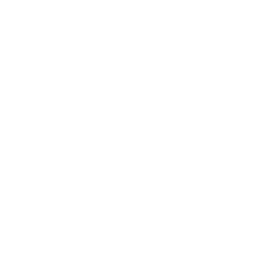
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">世代別設備信頼性分析</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 製造 / 信頼性エンジニアリング &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## エグゼクティブサマリー

この分析では**PROC LIFETEST**を使用して、CNCフライス盤の3世代にわたる設計世代の
現場信頼性を比較します。100台のプラントスナップショット(75件の故障、
25台は稼働継続中のため右側打ち切り)をもとに、各世代のカプラン・マイヤー生存曲線を
推定し、ログランク検定とGehan-Breslow-Wilcoxon検定の両方で曲線に差があるかを検定します。

データは明確な、単一段階の変化を示しています。最初の**第1世代**機械は
後続の2つの設計より明らかに信頼性が低く、その中央生存期間は**5,282稼働時間**であり、
これは**第2世代**(**16,430時間**)と**第3世代**(**13,512時間**)の
約3分の1です。両方の均一性検定とも3つの生存曲線の同一性を棄却しています――
ログランドのカイ二乗値**12.92**(自由度2、*p* = **0.0016**)、Wilcoxon検定
**11.88**(自由度2、*p* = **0.0026**)です。10,000稼働時間の時点で、第1世代機械が
稼働継続していると期待されるのは**24%**のみで、第2世代は**64%**、
第3世代は**57%**です。

この改善は**世代を追うごとの段階的な**向上ではありません。第2世代と第3世代は
非常に近い生存率を示し、このサンプルサイズでは互いに統計的に区別できません。
実用上重要な発見は第1世代から再設計後のフリートへの段階的変化であり、
これが残存する第1世代機の更新および予防保全の優先順位を決定づけるべきです。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|---------|
| WORK.EQUIPMENT_LIFE | CNC機械1台につき1行: 設計世代、プラント、導入年、故障または最終観測時点の稼働時間、故障/打ち切り指標 | 100 |

このデータセットは合成であり、固定シード(`streaminit(42)`)を用いて
次のセルで生成されるため、分析は完全に再現可能です。稼働寿命は世代ごとの
指数分布モデルから抽出され、新しい世代ほど稼働年数(暦年)が短いため
打ち切り割合が高くなります。

---

In [1]:
/* --------------------------------------------------------
   合成の設備信頼性データセットを生成する。

   各行は1台のCNCフライス盤を表す。OPERATING_HOURSは、機械が
   故障した(FAILURE_EVENT=1)か、最後に稼働中と観測された
   (FAILURE_EVENT=0、右側打ち切り)時点の稼働時間である。
   3つの設計世代には段階的に大きい平均寿命を与え、再設計が
   実際に現場信頼性を改善したかを検証できるようにしている。

   このアンライセンス環境では出力が100観測に制限されるため、
   ちょうど100台の機械をモデル化する――現実的な単一プラントの
   フリートスナップショットである。
   -------------------------------------------------------- */
データ work.equipment_life;
    呼出 streaminit(42);
    配列 fail_scale[3]       _temporary_ (8000 12000 16000);
    長さ generation $16 plant_location $16 failure_mode $16;
    繰返 equip_seq = 1 から 100;
        equipment_id = cat('CNC-', PUT(equip_seq, z5.));
        gen_idx     = int(rand('uniform') * 3) + 1;
        もし      gen_idx = 1 なら generation = "第1世代";
        他 もし gen_idx = 2 なら generation = "第2世代";
        他                     generation = "第3世代";
        plant_idx       = int(rand('uniform') * 5) + 1;
        もし      plant_idx = 1 なら plant_location = "北工場";
        他 もし plant_idx = 2 なら plant_location = "南工場";
        他 もし plant_idx = 3 なら plant_location = "東工場";
        他 もし plant_idx = 4 なら plant_location = "西工場";
        他                       plant_location = "中央工場";
        install_year = 2018 + (gen_idx - 1) * 2
                            + int(rand('uniform') * 2);
        /* 指数分布に従う稼働寿命、世代でスケーリング */
        operating_hours = round(rand('exponential')
                                * fail_scale[gen_idx] + 500, 1);
        /* 新しい世代は現場での暦年数が短いため、稼働継続中
           (打ち切り)の台数が多くなる。 */
        censor_rate = 0.20 + (gen_idx - 1) * 0.08;
        もし rand('uniform') < censor_rate なら failure_event = 0;
        他                                  failure_event = 1;
        /* 観測された故障事象の故障モードを分類する */
        もし failure_event = 1 なら 繰返;
            もし      operating_hours <  2000 なら failure_mode = "初期故障";
            他 もし operating_hours < 20000 なら failure_mode = "偶発故障";
            他                                 failure_mode = "摩耗故障";
        終了;
        他 failure_mode = ' ';
        出力;
    終了;
    削除 equip_seq gen_idx plant_idx censor_rate;
実行;


NOTE: DATA work.equipment_life


NOTE: Wrote work.equipment_life (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                                   The FREQ Procedure

Table of 世代 by 故障発生

世代         |         0 |         1 |      Total
-----------+-----------+-----------+-----------
第1世代       |         2 |        29 |         31
-----------+-----------+-----------+-----------
第2世代       |        12 |        26 |         38
-----------+-----------+-----------+-----------
第3世代       |        11 |        20 |         31
-----------+-----------+-----------+-----------
Total      |        25 |        75 |        100


Table of 世代 by 故障モード

世代         |             |        偶発故障 |        初期故障 |        摩耗故障 |        Total
-----------+-------------+-------------+-------------+-------------+-------------
第1世代       |           2 |          21 |           5 |           3 |           31
           |        2.00 |       21.00 |        5.00 |        3.00 |        31.00
-----------+-------------+-------------+-------------+-------------+-------------
第2世代       |          12 |          19 |  


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_generation_failure_event.spec.json
NOTE: ODS plot written: freq_mosaic_generation_failure_mode.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


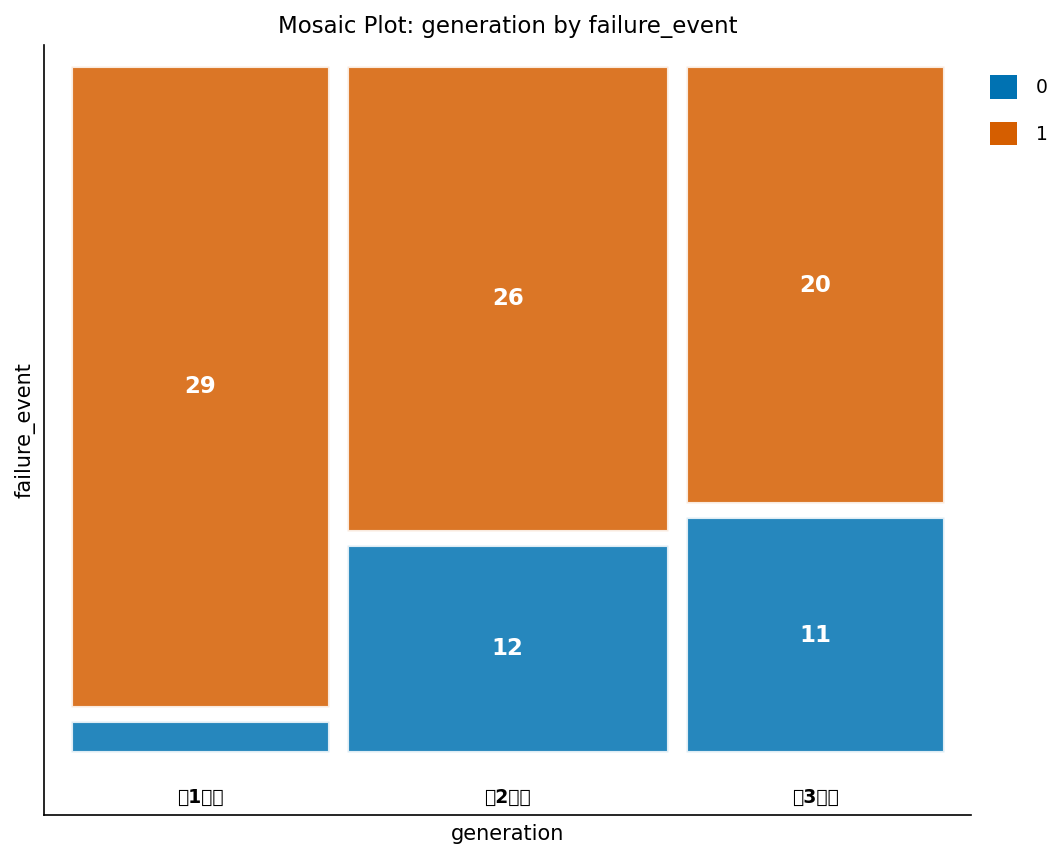

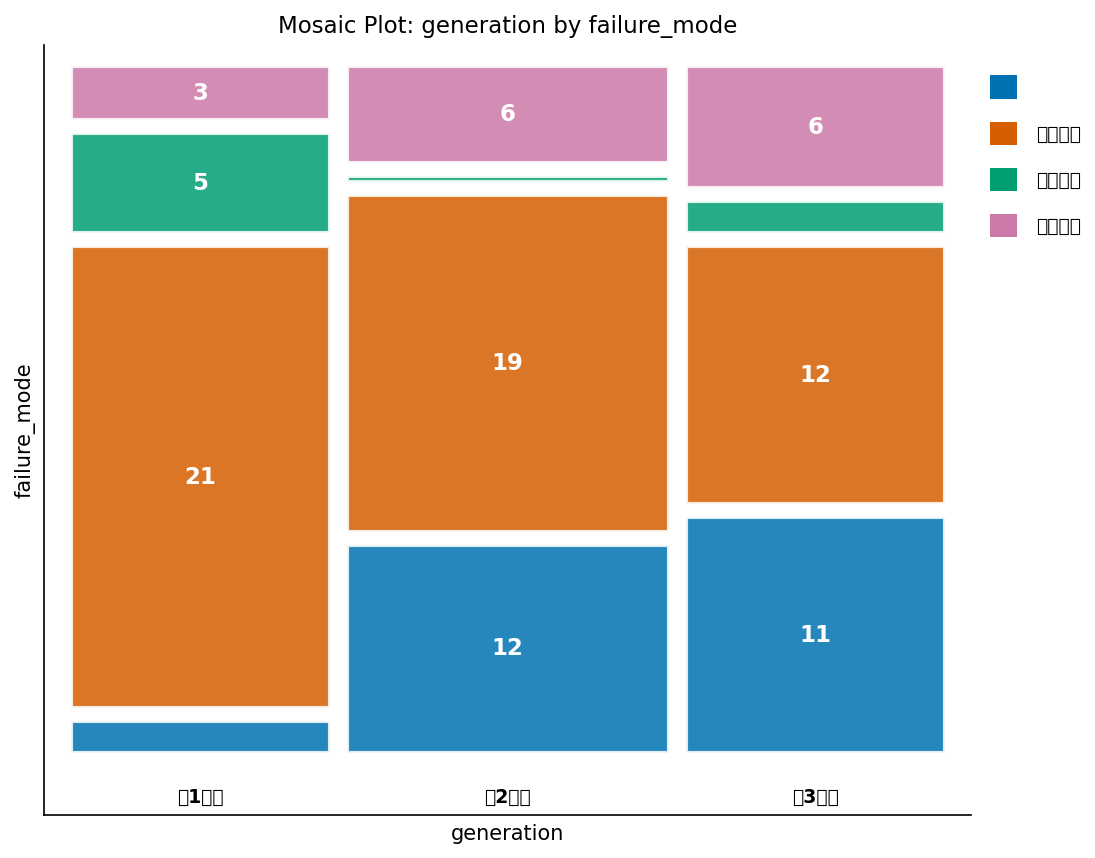

In [2]:
/* --------------------------------------------------------
   世代別のベースライン設備台数と稼働時間
   -------------------------------------------------------- */
処理 度数 データ=work.equipment_life;
    TABLES generation * failure_event / nocol nopercent;
    TABLES generation * failure_mode / nocol norow;
    見出 generation    = "世代"
          failure_event = "故障発生"
          failure_mode  = "故障モード";
実行;

処理 平均 データ=work.equipment_life n mean std;
    分類 generation;
    変数 operating_hours;
    見出 generation     = "世代"
          operating_hours = "稼働時間";
実行;

---


NOTE: PROC SGPLOT data=work.equipment_life

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


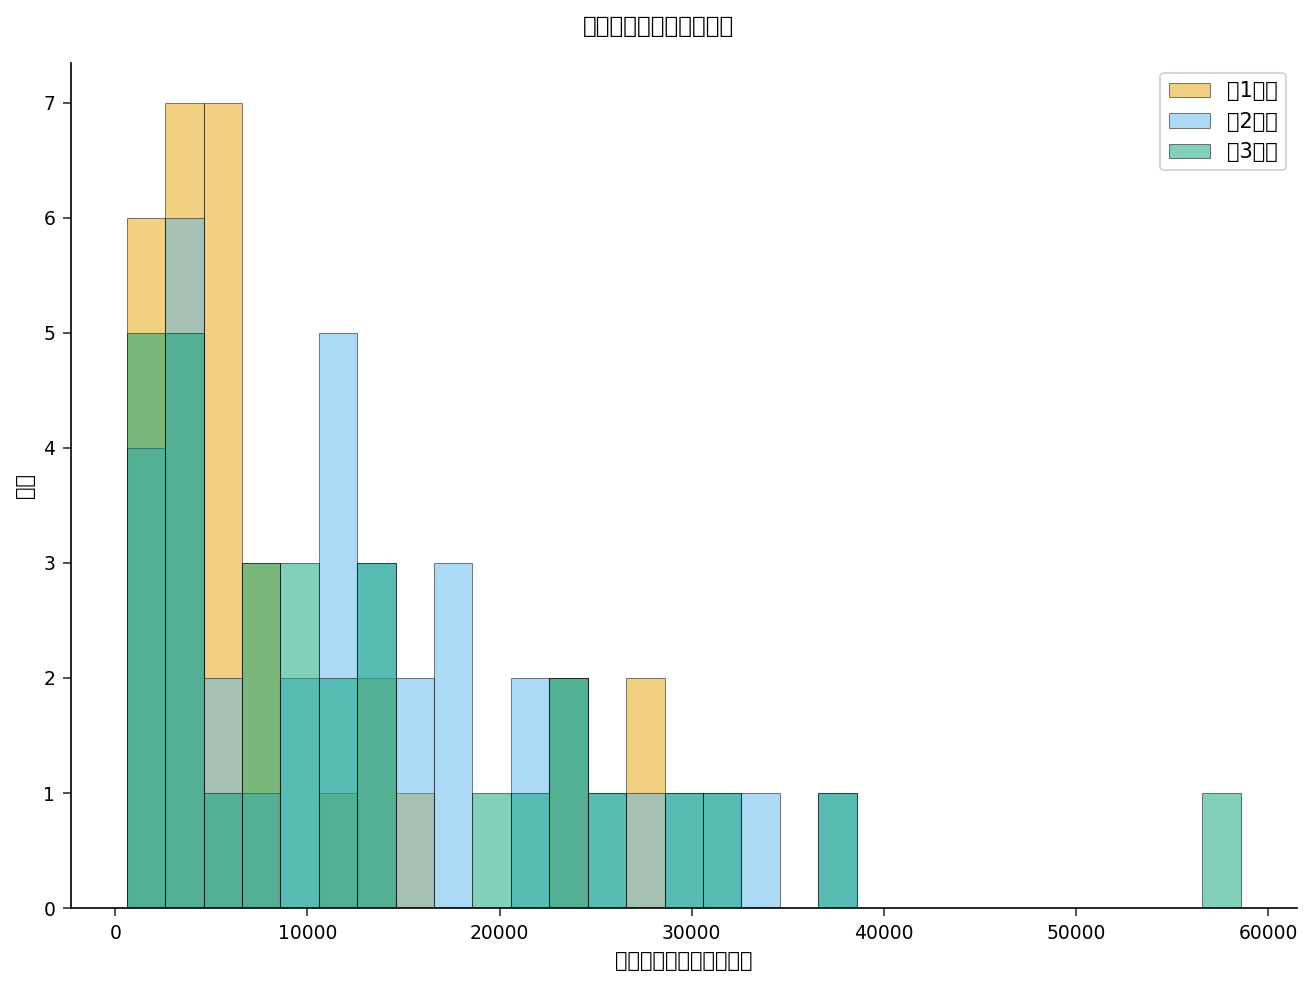

In [3]:
/* --------------------------------------------------------
   世代別の稼働時間分布
   -------------------------------------------------------- */
処理 SGPLOT データ=work.equipment_life;
    HISTOGRAM operating_hours / GROUP=generation TRANSPARENCY=0.3 BINWIDTH=2000;
    XAXIS 見出='イベントまでの稼働時間';
    YAXIS 見出='度数';
    表題 '世代別設備稼働時間分布';
実行;

---

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

Stratum: generation = 第1世代

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065    


NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: OUTSURV dataset 'work.equip_cumhaz' written to: ./work/35874b67-e4cd-4c37-ba8e-5698c672212d/equip_cumhaz.avro
NOTE: ODS plot written: lifetest_hazard.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


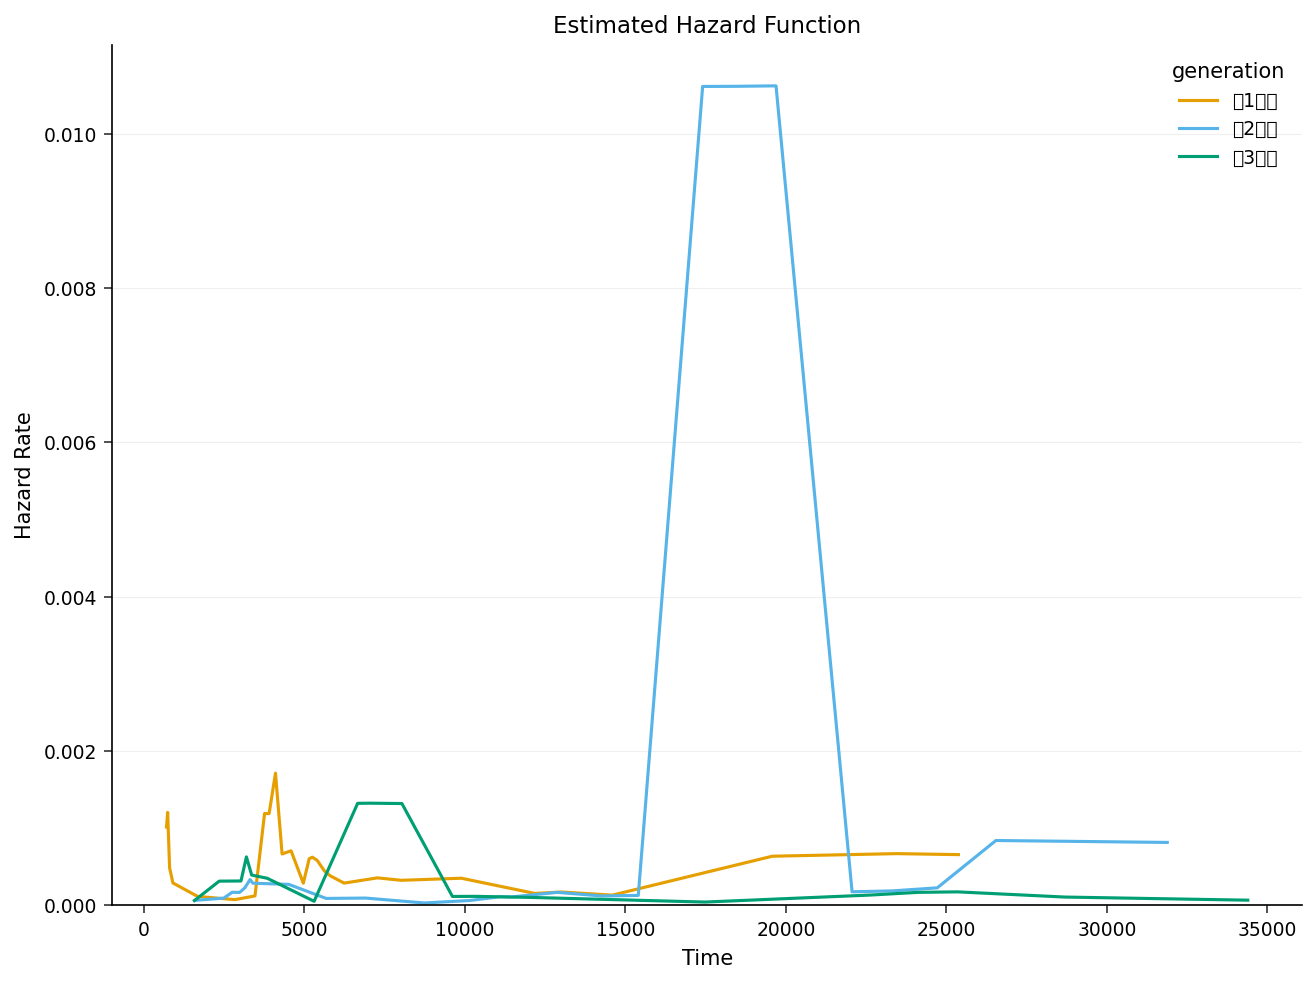

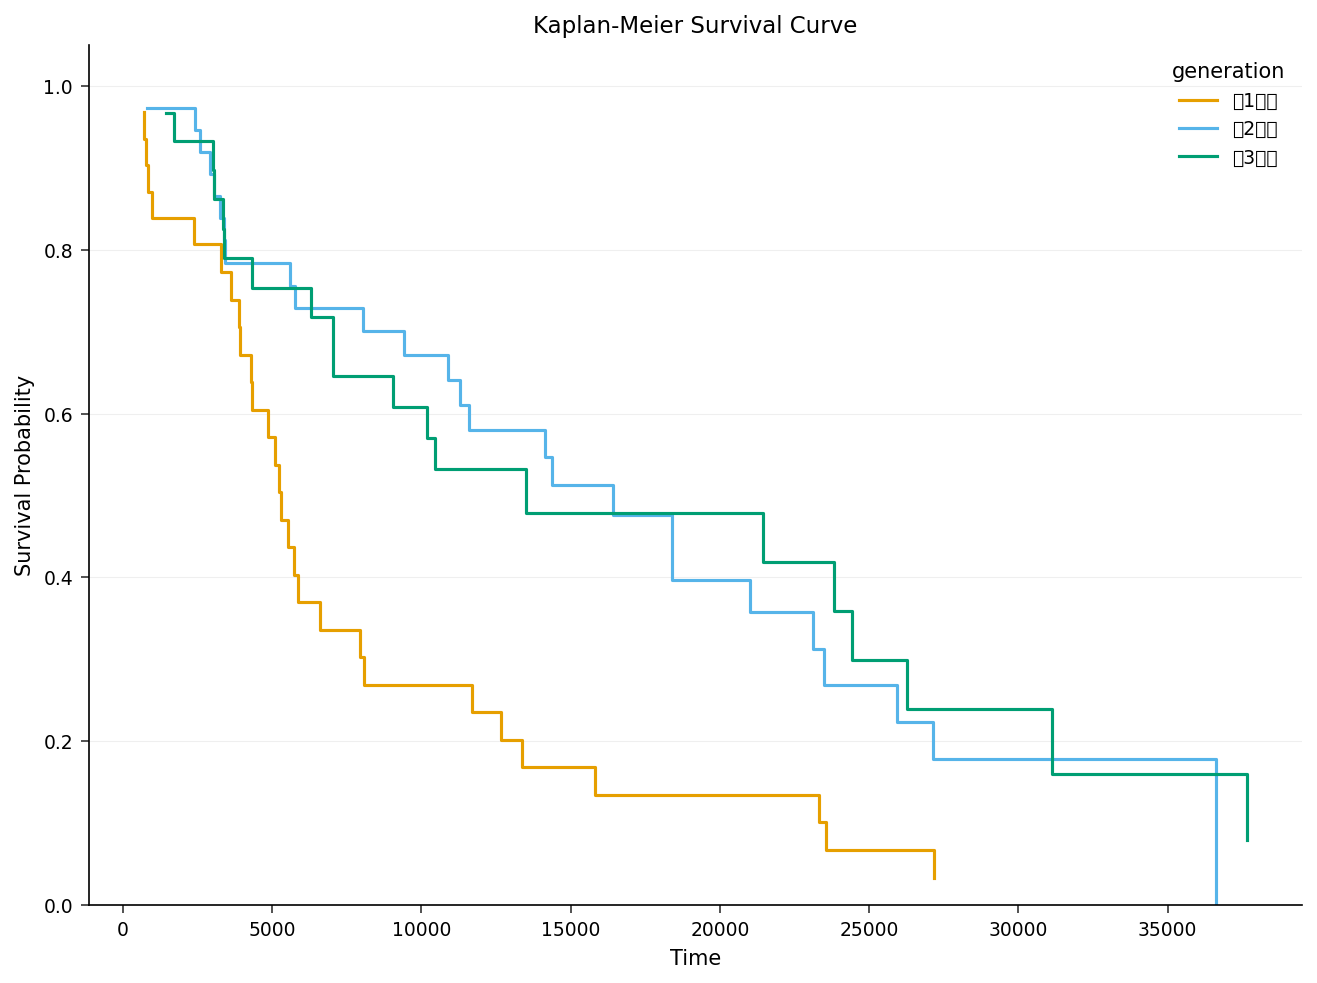

In [4]:
/* --------------------------------------------------------
   世代別のカプラン・マイヤー生存推定。ハザードビュー用に
   Nelson-Aalen累積ハザードオプションを付与する。

   STRATA generation / TEST=(LOGRANK WILCOXON) は、ログランク検定
   (稼働寿命全体の差に敏感)とGehan-Breslow-Wilcoxon検定
   (初期の故障を重視する)の両方を3つの世代にわたって実行する。

   PLOTS=(SURVIVAL HAZARD) はカプラン・マイヤー生存曲線と
   カーネル平滑化ハザード関数を描画する。
   -------------------------------------------------------- */
処理 LIFETEST データ=work.equipment_life
    METHOD=km
    nelson
    PLOTS=(SURVIVAL hazard)
    outsurv=work.equip_cumhaz;
    TIME operating_hours * failure_event(0);
    層 generation / TEST=(logrank WILCOXON);
実行;

In [5]:
/* --------------------------------------------------------
   各世代について、稼働時間のマイルストーン
   (5,000 / 10,000 / 20,000 / 30,000時間)における生存確率を
   カプラン・マイヤーODSテーブルから読み取る。
   -------------------------------------------------------- */
ODS 出力 productlimitestimates=work.equip_km_detail;

処理 LIFETEST データ=work.equipment_life METHOD=km;
    TIME operating_hours * failure_event(0);
    層 generation;
実行;

ODS 出力 CLOSE;

/* ProductLimitEstimatesテーブルには、各世代内の個別の時点ごとに
   1行が含まれる。各マイルストーンについて、その時点以上となる
   最初の行――つまりその稼働時間における生存推定値――を保持する。 */
処理 並替 データ=work.equip_km_detail;
    基準 generation operating_hours;
実行;

データ work.equip_milestones;
    設定 work.equip_km_detail;
    基準 generation;
    保存 hit5 hit10 hit20 hit30;
    もし first.generation なら 繰返;
        hit5 = 0; hit10 = 0; hit20 = 0; hit30 = 0;
    終了;
    長さ milestone 8;
    milestone = .;
    もし      operating_hours >= 5000  かつ hit5  = 0 なら 繰返; milestone = 5000;  hit5  = 1; 終了;
    他 もし operating_hours >= 10000 かつ hit10 = 0 なら 繰返; milestone = 10000; hit10 = 1; 終了;
    他 もし operating_hours >= 20000 かつ hit20 = 0 なら 繰返; milestone = 20000; hit20 = 1; 終了;
    他 もし operating_hours >= 30000 かつ hit30 = 0 なら 繰返; milestone = 30000; hit30 = 1; 終了;
    もし milestone ne .;
    保持 generation milestone operating_hours SURVIVAL sdf_stderr;
実行;

処理 印刷 データ=work.equip_milestones noobs 見出;
    見出 generation     = "世代"
          milestone       = "マイルストーン(時間)"
          operating_hours = "推定時点"
          SURVIVAL        = "生存確率"
          sdf_stderr      = "標準誤差";
    書式 SURVIVAL sdf_stderr 6.4;
    表題 '世代別・稼働時間マイルストーンにおける生存確率';
実行;

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

Stratum: generation = 第1世代

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065    


NOTE: ODS OUTPUT: PRODUCTLIMITESTIMATES -> equip_km_detail
NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS OUTPUT: ProductLimitEstimates written to 'equip_km_detail'.
NOTE: PROC LIFETEST completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC SORT data=work.equip_km_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_km_detail (75 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.equip_milestones


NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_milestones (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=work.equip_milestones

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


---

### 解釈

カプラン・マイヤー生存曲線は、フリートを2つの明確な階層に分けています。
最初の**第1世代**機械は最も早く故障します。その曲線は**5,282稼働時間**
(中央生存期間)で0.5を下回り、10,000時間の時点で稼働継続しているのは
約**24%**にすぎません。再設計された**第2世代**と**第3世代**の機械は
はるかに長く生存し――中央生存期間はそれぞれ**16,430**時間と**13,512**時間――
その生存曲線は観測期間全体を通じて互いに近接しています。5,000 / 10,000 /
20,000時間のマイルストーンにおける推定生存確率は次のとおりです。

| 世代 | 5,000時間 | 10,000時間 | 20,000時間 |
|------------|--------:|---------:|---------:|
| 第1世代 | 0.54 | 0.24 | 0.10 |
| 第2世代 | 0.76 | 0.64 | 0.36 |
| 第3世代 | 0.72 | 0.57 | 0.42 |

両方の層間均一性検定とも、3つの世代が単一の生存分布を共有するという
帰無仮説を棄却しています。**ログランク**検定はカイ二乗値**12.92**
(自由度2、*p* = **0.0016**)、**Gehan-Breslow-Wilcoxon**検定は
カイ二乗値**11.88**(自由度2、*p* = **0.0026**)を示します。両検定は
近い結果を示しており、この差が初期故障領域だけでなく(Wilcoxon検定は
初期のイベントを重視します)、稼働寿命全体にわたって生じていることが
わかります。

これは**単一段階**の改善として読むべきであり、世代を追うごとの単調な
向上ではないことに注意が必要です。第2世代と第3世代はここでは統計的に
区別できません――両者の曲線は重なり合い、第2世代の中央値は名目上
やや高いものの――この100台のサンプルでは第3世代が第2世代より改善した
という証拠はありません。真のシグナルは、最初の第1世代設計と後続の
2つの設計との間の大きく有意な差です。

Nelson-Aalen累積ハザードオプションが付随するハザードプロットを
生成します。このサンプルサイズではカーネル平滑化ハザードにノイズが
多く――18,000時間付近に見られる第2世代の高いスパイクは、真の摩耗故障の
急増ではなく、残存リスク集合が小さい中での単一のイベントを反映した
ものです――そのためハザードビューは定性的なものとして扱うべきであり、
定量的な結論は生存曲線と正式な検定が担っています。

**推奨事項。** 残存する第1世代機械の更新と、より厳格な点検を優先すべきです。
その信頼性はフリートの他の部分より明らかに劣っています。第2世代と
第3世代は、両者の差をより大きなサンプルで解決できるまで、保全計画上は
単一のより信頼性の高いコホートとして扱ってください。

---

In [6]:
/* --------------------------------------------------------
   累積ハザード/生存曲線データとマイルストーン生存表を
   下流の信頼性ダッシュボード向けにエクスポートする。
   -------------------------------------------------------- */
処理 EXPORT データ=work.equip_cumhaz
    OUTFILE='equipment_cumulative_hazard.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.equip_milestones
    OUTFILE='equipment_milestone_survival.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.equip_cumhaz outfile=equipment_cumulative_hazard.csv

NOTE: Exported 75 rows to equipment_cumulative_hazard.csv.
NOTE: PROC EXPORT data=work.equip_milestones outfile=equipment_milestone_survival.csv

NOTE: Exported 11 rows to equipment_milestone_survival.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密情報
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Jenner提供 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>